In [2]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np


from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.semi_supervised import LabelSpreading , SelfTrainingClassifier
from sklearn.svm import SVC


In [9]:
iris = load_iris()
X= iris.data[:, :2]
y= iris.target


In [4]:
rng = np.random.RandomState(42)
y_rand= rng.rand(y.shape[0])
y_10= np.copy(y)
y_10[y_rand < 0.1] = -1 #set random samples to be unlabeled 
y_30 = np.copy(y)
y_30[y_rand < 0.3] = -1 #set random samples to be unlabeled

In [10]:
ls10 = (LabelSpreading().fit(X,y_10), y_10, "LabelSpreading with 10% labeled data")
ls30 = (LabelSpreading().fit(X,y_30), y_30, "LabelSpreading with 30% labeled data")
ls100= (LabelSpreading().fit(X,y), y, "LabelSpreading with 100% labeled data")

In [13]:
base_classifier = CalibratedClassifierCV(SVC(gamma=0.5, random_state=42))
st10 = (
    SelfTrainingClassifier(base_classifier).fit(X, y_10),
    y_10,
    "Self-training with 10% labeled data",
)
st30 = (
    SelfTrainingClassifier(base_classifier).fit(X, y_30),
    y_30,
    "Self-training with 30% labeled data",
)
rbf_svc = (
    base_classifier.fit(X, y),
    y,
    "SVC with rbf kernel\n(equivalent to Self-training with 100% labeled data)",
)

classifiers = (ls10, st10, ls30, st30, ls100, rbf_svc)

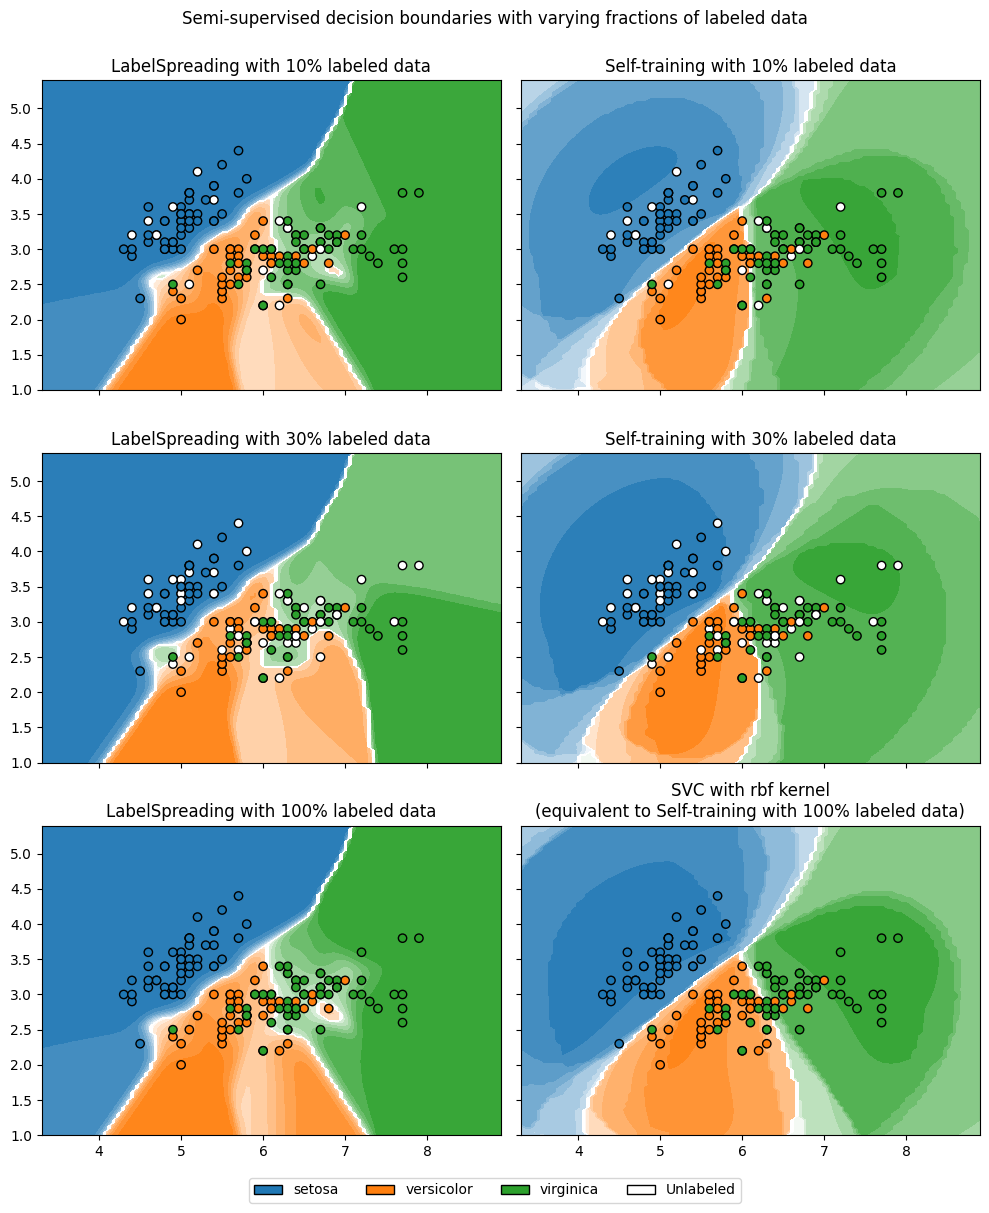

In [14]:
fig, axes = plt.subplots(nrows=3, ncols=2, sharex="col", sharey="row", figsize=(10, 12))
axes = axes.ravel()
for ax, (clf, y_train, title) in zip(axes, classifiers):
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        response_method="predict_proba",
        plot_method="contourf",
        ax=ax,
    )
    colors = [
        (1, 1, 1, 1) if label == -1 else disp.multiclass_colors_[label]
        for label in y_train
    ]
    ax.scatter(X[:, 0], X[:, 1], c=colors, edgecolor="black")
    ax.set_title(title)
fig.suptitle(
    "Semi-supervised decision boundaries with varying fractions of labeled data", y=1
)
handles = [
    mpatches.Patch(
        facecolor=color, edgecolor="black", label=iris.target_names[class_idx]
    )
    for class_idx, color in enumerate(disp.multiclass_colors_)
]
handles.append(mpatches.Patch(facecolor="white", edgecolor="black", label="Unlabeled"))
fig.legend(
    handles=handles, loc="lower center", ncol=len(handles), bbox_to_anchor=(0.5, 0.0)
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()